In [57]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    adjusted_rand_score,
    f1_score,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

In [79]:
df = pd.read_csv("../data/df_EDA_cleaned.csv")

import sys
import os

sys.path.append(os.path.abspath(".."))
from src.config import *

np.random.seed(RANDOM_STATE)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "sans-serif",
        "font.size": 12,
    }
)

plt.style.use("seaborn-v0_8-colorblind")
theme_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 2. Compute Embeddings (Sentence-BERT)

In [68]:
sbert_mini = SentenceTransformer("all-MiniLM-L6-v2")
embeddings_mini = sbert_mini.encode(
    df["combined_short"].tolist(), show_progress_bar=True, batch_size=64
)
np.save("../data/embeddings/embeddings_mini.npy", embeddings_mini)
print(f"MiniLM embeddings shape: {embeddings_mini.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7884.32it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 61/61 [00:05<00:00, 10.94it/s]

MiniLM embeddings shape: (3855, 384)


In [69]:
sbert_mpnet = SentenceTransformer("all-mpnet-base-v2")
embeddings_mpnet = sbert_mpnet.encode(
    df["combined_short"].tolist(), show_progress_bar=True, batch_size=32
)
np.save("../data/embeddings/embeddings_mpnet.npy", embeddings_mpnet)
print(f"MPNet embeddings shape: {embeddings_mpnet.shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8510.06it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 121/121 [00:30<00:00,  4.02it/s]


MPNet embeddings shape: (3855, 768)


# Unsupervised Learning

### A1. Baseline — TF-IDF + NMF Topic Modeling

In [70]:
# TF-IDF on combined text (no token limit issues with classical methods)
tfidf_vec = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english",
    min_df=5,
    max_df=0.95,
)
tfidf_matrix = tfidf_vec.fit_transform(df["combined_text"])
print(f"TF-IDF matrix: {tfidf_matrix.shape}")

TF-IDF matrix: (3855, 10000)


In [71]:
N_TOPICS = 8

nmf = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE, max_iter=400)
nmf_topics = nmf.fit_transform(tfidf_matrix)

feature_names = tfidf_vec.get_feature_names_out()

print("=== NMF Topics (TF-IDF baseline) ===\n")
for i, topic in enumerate(nmf.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-12:][::-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

# Assign dominant topic to each document
df["nmf_topic"] = nmf_topics.argmax(axis=1)
print(
    f"\nTopic distribution:\n{pd.Series(df['nmf_topic']).value_counts().sort_index()}"
)

=== NMF Topics (TF-IDF baseline) ===

Topic 0: food, day, year, restaurant, open, life, family, thing, love, way, event, make
Topic 1: game, team, coach, class, season, player, win, play, senior, scored, yard, second
Topic 2: police, crash, man, county, investigation, vehicle, according, office, road, department, scene, sheriff
Topic 3: republican, democrat, senate, trump, collins, democratic, platner, campaign, candidate, election, sen, race
Topic 4: project, city, council, board, housing, town, cost, community, million, plan, public, building
Topic 5: immigration, ice, agent, enforcement, federal, immigrant, custom, operation, law, detained, immigration custom, custom enforcement
Topic 6: varsity, high school, school, sport, poll, high, school sport, coverage proudly, supported bymaine, sport coverage, proudly supported, bymaine credit
Topic 7: fact brief, brief, fact, check, claim, brief responsive, asthis, conversation asthis, responsive conversation, fact check, ourmethodologyto l

### A2. SBERT Embeddings + UMAP + HDBSCAN (Density-Based Clustering)

In [72]:
embeddings_mini = np.load("../data/embeddings/embeddings_mini.npy")
embeddings_mpnet = np.load("../data/embeddings/embeddings_mpnet.npy")
print(f"MiniLM embeddings shape: {embeddings_mini.shape}")
print(f"MPNet embeddings shape:  {embeddings_mpnet.shape}")

MiniLM embeddings shape: (3855, 384)
MPNet embeddings shape:  (3855, 768)


In [82]:
# UMAP dimensionality reduction (high-dim embeddings → 5D for clustering, 2D for viz)
umap_5d = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE
)
umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)

reduced_5d = umap_5d.fit_transform(embeddings_mini)
reduced_2d = umap_2d.fit_transform(embeddings_mini)
print(f"UMAP 5D: {reduced_5d.shape}, UMAP 2D: {reduced_2d.shape}")

UMAP 5D: (3855, 5), UMAP 2D: (3855, 2)


In [83]:
# HDBSCAN clustering on 5D UMAP embeddings
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
)
hdb_labels = clusterer.fit_predict(reduced_5d)

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
print(
    f"HDBSCAN found {n_clusters} clusters, {n_noise} noise points ({n_noise/len(hdb_labels)*100:.1f}%)"
)
print(f"Cluster sizes: {dict(Counter(hdb_labels).most_common())}")

df["hdbscan_cluster"] = hdb_labels

HDBSCAN found 16 clusters, 706 noise points (18.3%)
Cluster sizes: {np.int64(-1): 706, np.int64(0): 577, np.int64(12): 382, np.int64(14): 324, np.int64(2): 301, np.int64(5): 261, np.int64(13): 232, np.int64(10): 172, np.int64(7): 161, np.int64(6): 144, np.int64(8): 111, np.int64(4): 101, np.int64(15): 94, np.int64(1): 89, np.int64(9): 89, np.int64(11): 59, np.int64(3): 52}


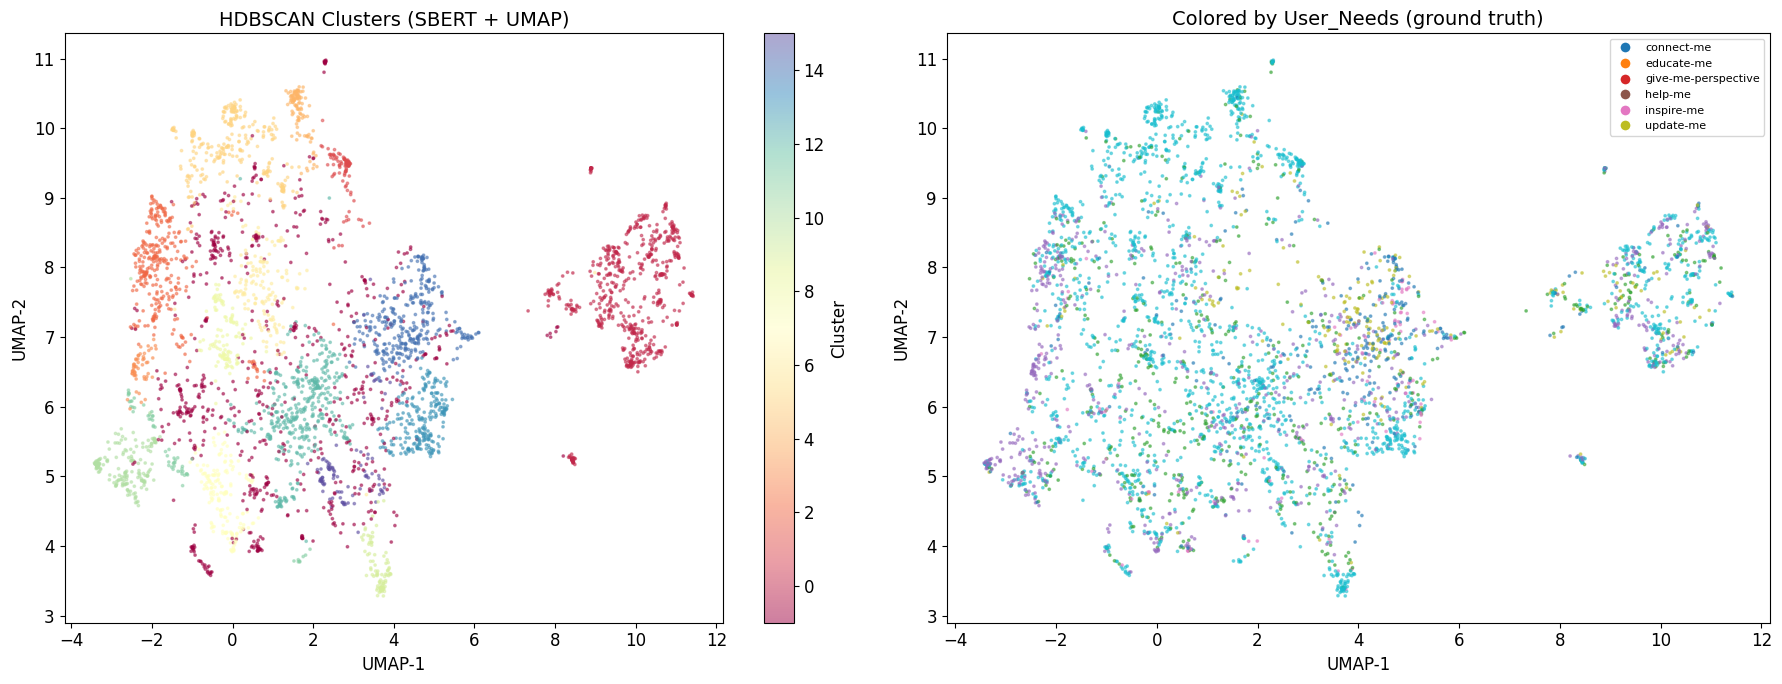

In [84]:
# Visualize HDBSCAN clusters in 2D UMAP space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: HDBSCAN clusters
scatter = axes[0].scatter(
    reduced_2d[:, 0], reduced_2d[:, 1], c=hdb_labels, cmap="Spectral", s=3, alpha=0.5
)
axes[0].set_title("HDBSCAN Clusters (SBERT + UMAP)", fontsize=14)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

# Plot 2: Colored by User_Needs for comparison
le_viz = LabelEncoder()
needs_encoded = le_viz.fit_transform(df["User_Needs"])
scatter2 = axes[1].scatter(
    reduced_2d[:, 0], reduced_2d[:, 1], c=needs_encoded, cmap="tab10", s=3, alpha=0.5
)
axes[1].set_title("Colored by User_Needs (ground truth)", fontsize=14)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=plt.cm.tab10(i / len(le_viz.classes_)),
        markersize=8,
        label=c,
    )
    for i, c in enumerate(le_viz.classes_)
]
axes[1].legend(handles=handles, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

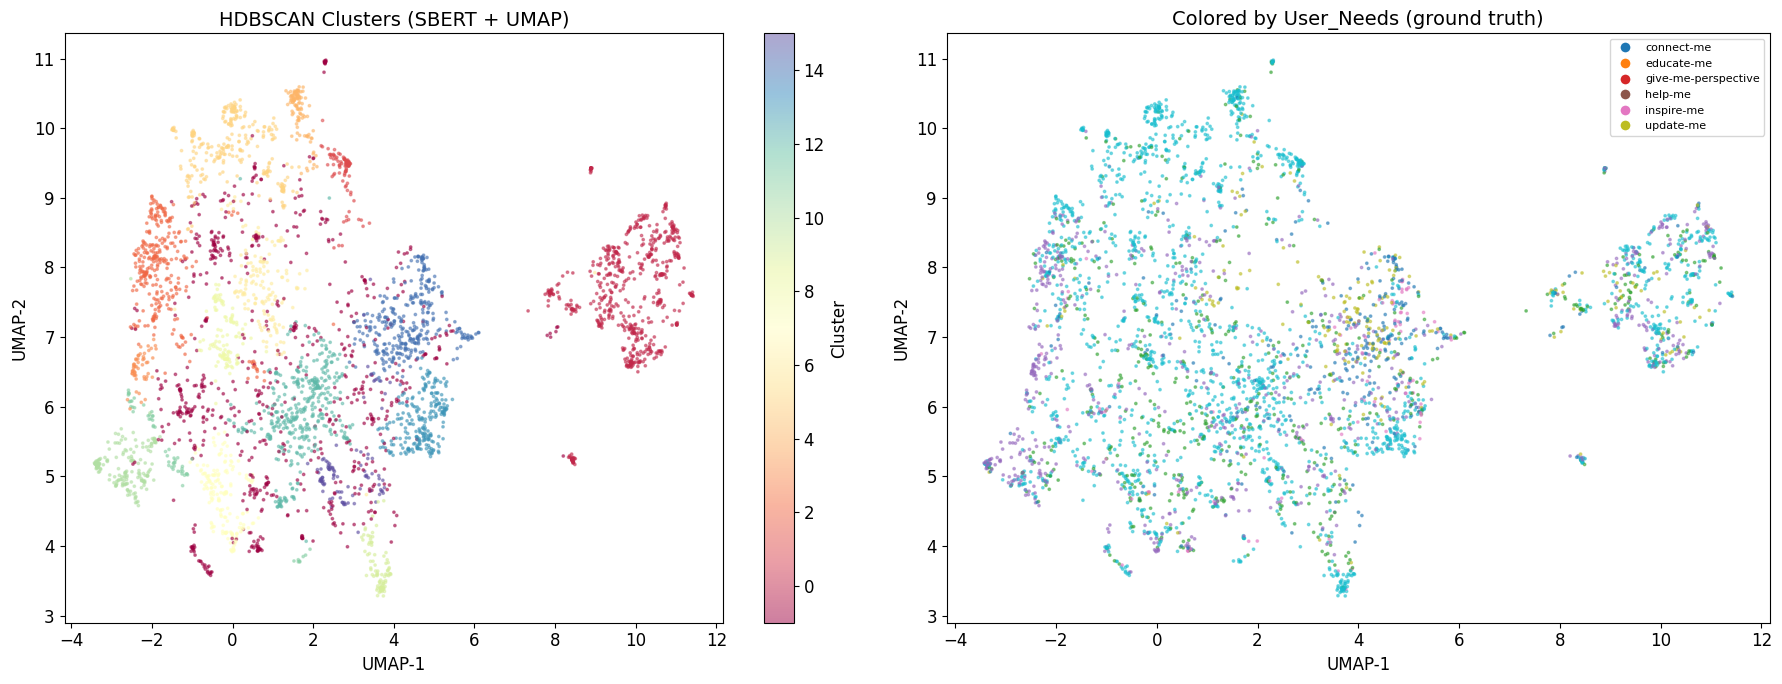

In [85]:
# Visualize HDBSCAN clusters in 2D UMAP space
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: HDBSCAN clusters
scatter = axes[0].scatter(
    reduced_2d[:, 0], reduced_2d[:, 1], c=hdb_labels, cmap="Spectral", s=3, alpha=0.5
)
axes[0].set_title("HDBSCAN Clusters (SBERT + UMAP)", fontsize=14)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

# Plot 2: Colored by User_Needs for comparison
le_viz = LabelEncoder()
needs_encoded = le_viz.fit_transform(df["User_Needs"])
scatter2 = axes[1].scatter(
    reduced_2d[:, 0], reduced_2d[:, 1], c=needs_encoded, cmap="tab10", s=3, alpha=0.5
)
axes[1].set_title("Colored by User_Needs (ground truth)", fontsize=14)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=plt.cm.tab10(i / len(le_viz.classes_)),
        markersize=8,
        label=c,
    )
    for i, c in enumerate(le_viz.classes_)
]
axes[1].legend(handles=handles, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

### A3. SBERT + K-Means

In [86]:
# Evaluate clustering quality
non_noise_mask = hdb_labels != -1
if non_noise_mask.sum() > 1 and len(set(hdb_labels[non_noise_mask])) > 1:
    sil = silhouette_score(reduced_5d[non_noise_mask], hdb_labels[non_noise_mask])
    print(f"Silhouette score (excl. noise): {sil:.4f}")

# Compare clusters to User_Needs labels (how well do unsupervised clusters align?)
ari = adjusted_rand_score(df["User_Needs"], hdb_labels)
print(f"Adjusted Rand Index vs User_Needs: {ari:.4f}")

# Show top titles per cluster
print("\n=== Sample titles per HDBSCAN cluster ===")
for cl in sorted(set(hdb_labels)):
    if cl == -1:
        continue
    subset = df[df["hdbscan_cluster"] == cl]
    print(f"\nCluster {cl} ({len(subset)} articles):")
    for t in (
        subset["Title"].sample(min(3, len(subset)), random_state=RANDOM_STATE).values
    ):
        print(f"  - {t[:100]}")

Silhouette score (excl. noise): 0.5518
Adjusted Rand Index vs User_Needs: 0.0121

=== Sample titles per HDBSCAN cluster ===

Cluster 0 (577 articles):
  - Colby football revels in best season in 20 years
  - Maine large-school boys basketball ready to go back to the future
  - Class B wide open at high school golf state championships

Cluster 1 (89 articles):
  - Man dies from burns in Augusta fire
  - A Naples equestrian center lost a 225-year-old barn in a fire. Within hours, the community had ralli
  - Double-wide home destroyed in Lewiston blaze

Cluster 2 (301 articles):
  - Mainers detained by ICE are coming home by the dozens
  - Maine must choose between fear and community safety | Opinion
  - Susan Collins says enhanced ICE operation is over in Maine; immigrant advocates urge vigilance

Cluster 3 (52 articles):
  - These 7 movies playing in Maine feel like rebellion in unsettling times
  - Trump’s declarations continue to threaten democracy | Opinion
  - Trump’s trying to buil

Best K by silhouette: 10 (score=0.4936)


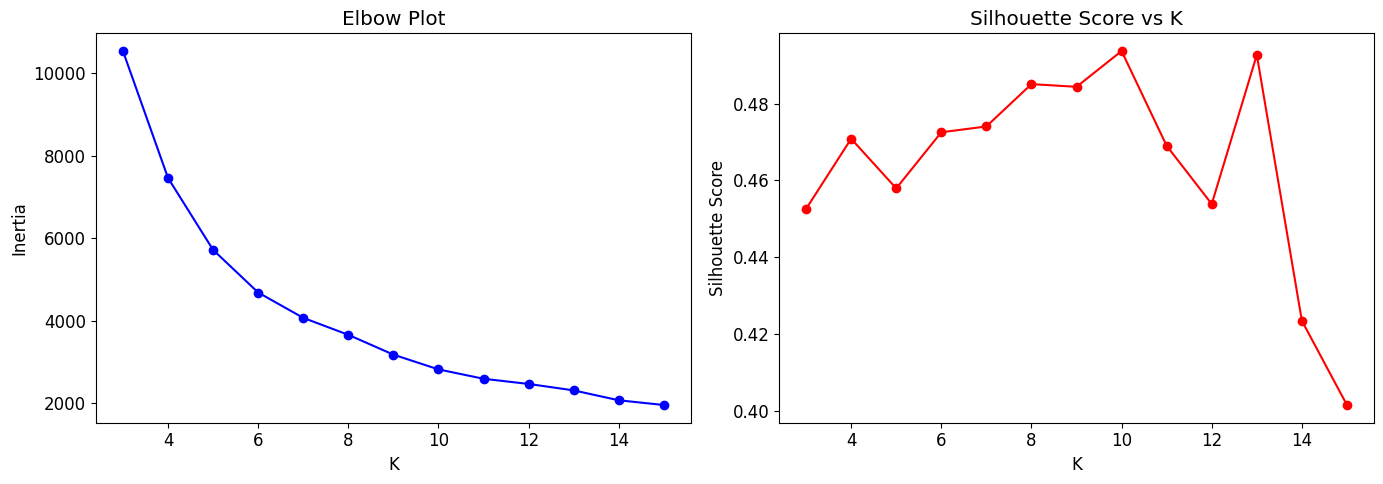

In [87]:
# Elbow / silhouette sweep for K-Means on UMAP-reduced embeddings
K_range = range(3, 16)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_k = km.fit_predict(reduced_5d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(reduced_5d, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, "bo-")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Plot")

axes[1].plot(K_range, sil_scores, "ro-")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best K by silhouette: {best_k} (score={max(sil_scores):.4f})")
plt.tight_layout()
plt.show()

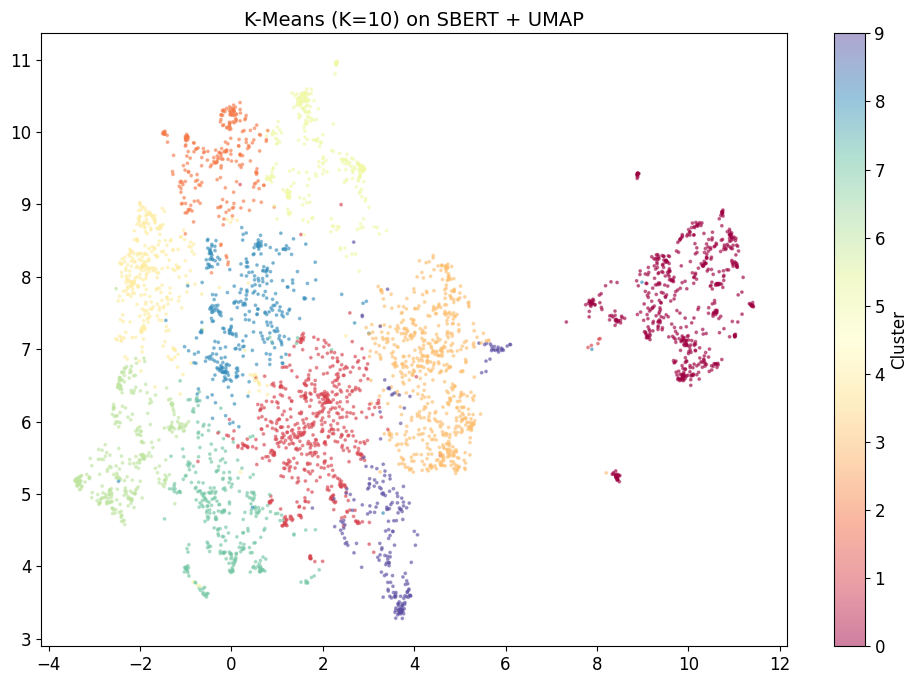

=== Sample titles per K-Means cluster (K=10) ===

Cluster 0 (577 articles):
  - Colby football revels in best season in 20 years
  - Maine large-school boys basketball ready to go back to the future
  - Class B wide open at high school golf state championships

Cluster 1 (577 articles):
  - Maine’s energy policy looks to be going up in smoke | Tux Turkel
  - Portland panel debates code changes that could make or break Live Nation venue
  - Topsham voters approve funding mechanism for workforce housing development

Cluster 2 (244 articles):
  - Maine towns are installing AI-enabled surveillance systems despite privacy concerns
  - Girls missing from Topsham elementary school found safe
  - Greene man pleads guilty to trafficking whale teeth, bird parts after monthslong undercover operatio

Cluster 3 (625 articles):
  - Surviving Maine’s 100-Mile Wilderness takes on new meaning in blockbuster novel
  - Roosevelt Trail historical sites welcome visitors as part of ‘history tour’
  - Abbioc

In [88]:
# Fit K-Means with best K
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["kmeans_cluster"] = km_best.fit_predict(reduced_5d)

# Visualize
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    reduced_2d[:, 0],
    reduced_2d[:, 1],
    c=df["kmeans_cluster"],
    cmap="Spectral",
    s=3,
    alpha=0.5,
)
ax.set_title(f"K-Means (K={best_k}) on SBERT + UMAP", fontsize=14)
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

# Show sample titles per K-Means cluster
print(f"=== Sample titles per K-Means cluster (K={best_k}) ===")
for cl in range(best_k):
    subset = df[df["kmeans_cluster"] == cl]
    print(f"\nCluster {cl} ({len(subset)} articles):")
    for t in (
        subset["Title"].sample(min(3, len(subset)), random_state=RANDOM_STATE).values
    ):
        print(f"  - {t[:100]}")

### A4. BERTopic — End-to-End Topic Modeling with Transformers

BERTopic is the SOTA topic modeling framework that chains:
**SBERT embeddings → UMAP → HDBSCAN → c-TF-IDF topic extraction**

It automatically determines the number of topics and provides rich topic representations.

In [89]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired

# Configure sub-components
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
)
vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = KeyBERTInspired()

if "sbert_mini" not in globals():
    sbert_mini = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model=sbert_mini,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    verbose=True,
)

In [90]:
# Fit BERTopic — pass pre-computed embeddings for speed
topics, probs = topic_model.fit_transform(
    df["combined_short"].tolist(), embeddings=embeddings_mini
)

df["bertopic_topic"] = topics
print(f"\nBERTopic found {len(set(topics)) - (1 if -1 in topics else 0)} topics")
print(f"Outliers (topic -1): {(np.array(topics) == -1).sum()}")

# Show top topics
topic_model.get_topic_info().head(15)

2026-04-21 20:46:36,049 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-21 20:46:44,737 - BERTopic - Dimensionality - Completed ✓
2026-04-21 20:46:44,743 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-21 20:46:44,801 - BERTopic - Cluster - Completed ✓
2026-04-21 20:46:44,807 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-21 20:46:45,934 - BERTopic - Representation - Completed ✓



BERTopic found 16 topics
Outliers (topic -1): 706


,Topic,Count,Name,Representation,Representative_Docs
0,-1,706,-1_officer_lawmaker_police_bureau,"[officer, lawmaker, police, bureau, activist, ...",[spruce mountain school jay area keep transgen...
1,0,577,0_kennebunk_coverage_scarborough_credit,"[kennebunk, coverage, scarborough, credit, ban...",[edward little girl basketball survives lewist...
2,1,382,1_downtown_scarborough_city_town,"[downtown, scarborough, city, town, street, ci...",[city council weighs future land slated failed...
3,2,324,2_waterville_downtown_family_farm,"[waterville, downtown, family, farm, event, vi...",[moviegoer look theater respite holiday hoopla...
4,3,301,3_law enforcement_enforcement_immigration enfo...,"[law enforcement, enforcement, immigration enf...",[live update susan collins say ice operation l...
5,4,261,4_district_street_sheriff office_county sheriff,"[district, street, sheriff office, county sher...",[school bus driver charged manslaughter rockla...
6,5,232,5_reopen_congress street_grocery_closing,"[reopen, congress street, grocery, closing, cl...",[abbiocco italian restaurant slated open thurs...
7,6,172,6_hancock county_public service_district_congr...,"[hancock county, public service, district, con...",[gov janet mill launch senate campaign tuesday...
8,7,161,7_department_federal government_federal_bureau,"[department, federal government, federal, bure...",[child care provider brace freeze federal aid ...
9,8,144,8_department_district_school district_school d...,"[department, district, school district, school...",[panel recommends removing george mitchell nam...


In [91]:
# BERTopic visualizations
fig_topics = topic_model.visualize_barchart(top_n_topics=10, n_words=8)
fig_topics.show()

In [92]:
# Topic similarity heatmap
fig_sim = topic_model.visualize_heatmap(top_n_topics=15)
fig_sim.show()

In [93]:
# 2D document visualization colored by BERTopic topic
fig_docs = topic_model.visualize_documents(
    df["Title"].tolist(), reduced_embeddings=reduced_2d, hide_annotations=True
)
fig_docs.show()

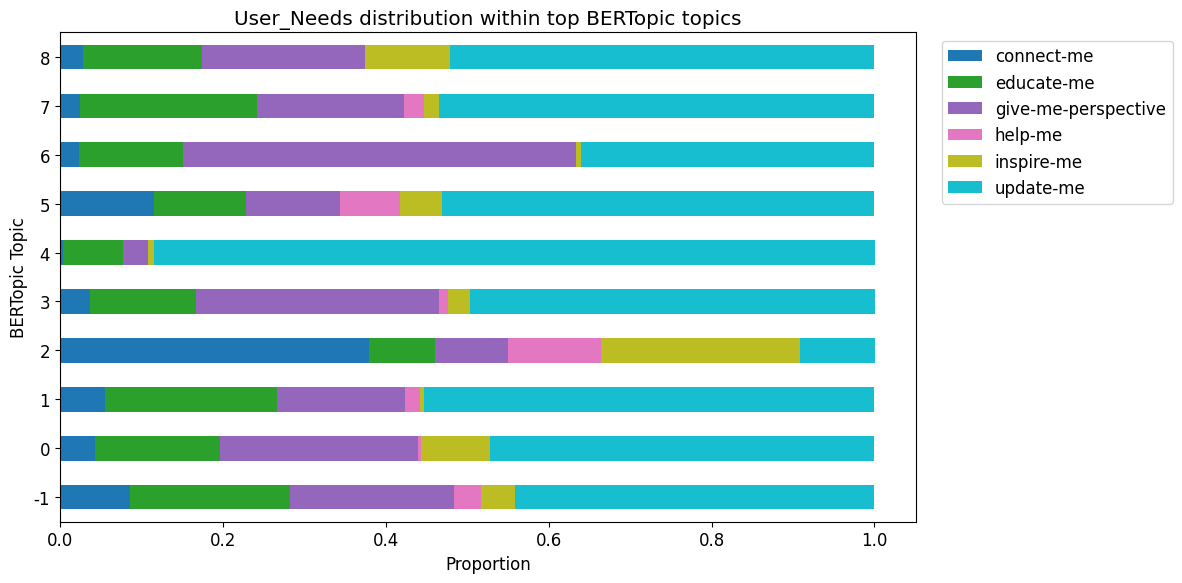

In [94]:
# Cross-tab: BERTopic topics vs User_Needs (do unsupervised topics align with labels?)
topic_needs_ct = pd.crosstab(
    df["bertopic_topic"], df["User_Needs"], normalize="index"
).round(3)

# Show for top 10 topics
top_topics = df["bertopic_topic"].value_counts().head(10).index.tolist()
display_ct = topic_needs_ct.loc[topic_needs_ct.index.isin(top_topics)]

fig, ax = plt.subplots(figsize=(12, 6))
display_ct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_title("User_Needs distribution within top BERTopic topics")
ax.set_xlabel("Proportion")
ax.set_ylabel("BERTopic Topic")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()